# Experiment 1 – Logistic Regression (Baseline)

## Mục tiêu
Trong notebook này, ta huấn luyện **Logistic Regression** trên bộ dữ liệu Titanic, 
với **các đặc trưng cơ bản (Exp1)**:
- Không sử dụng Feature Engineering nâng cao
- Chỉ bao gồm: `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`

Ta sẽ:
1. Thực hiện tiền xử lý dữ liệu
2. Khám phá dữ liệu (EDA cơ bản)
3. Huấn luyện Logistic Regression
4. Đánh giá mô hình và xuất kết quả


### 1. Khám phá dữ liệu 

In [11]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set(style="whitegrid")

train = pd.read_csv('/kaggle/input/titanic/train.csv')
test = pd.read_csv('/kaggle/input/titanic/test.csv')

print(train.shape, test.shape)
train.head()


(891, 12) (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 2. Biểu đồ phân bố biến đầu vào và biến đầu ra

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


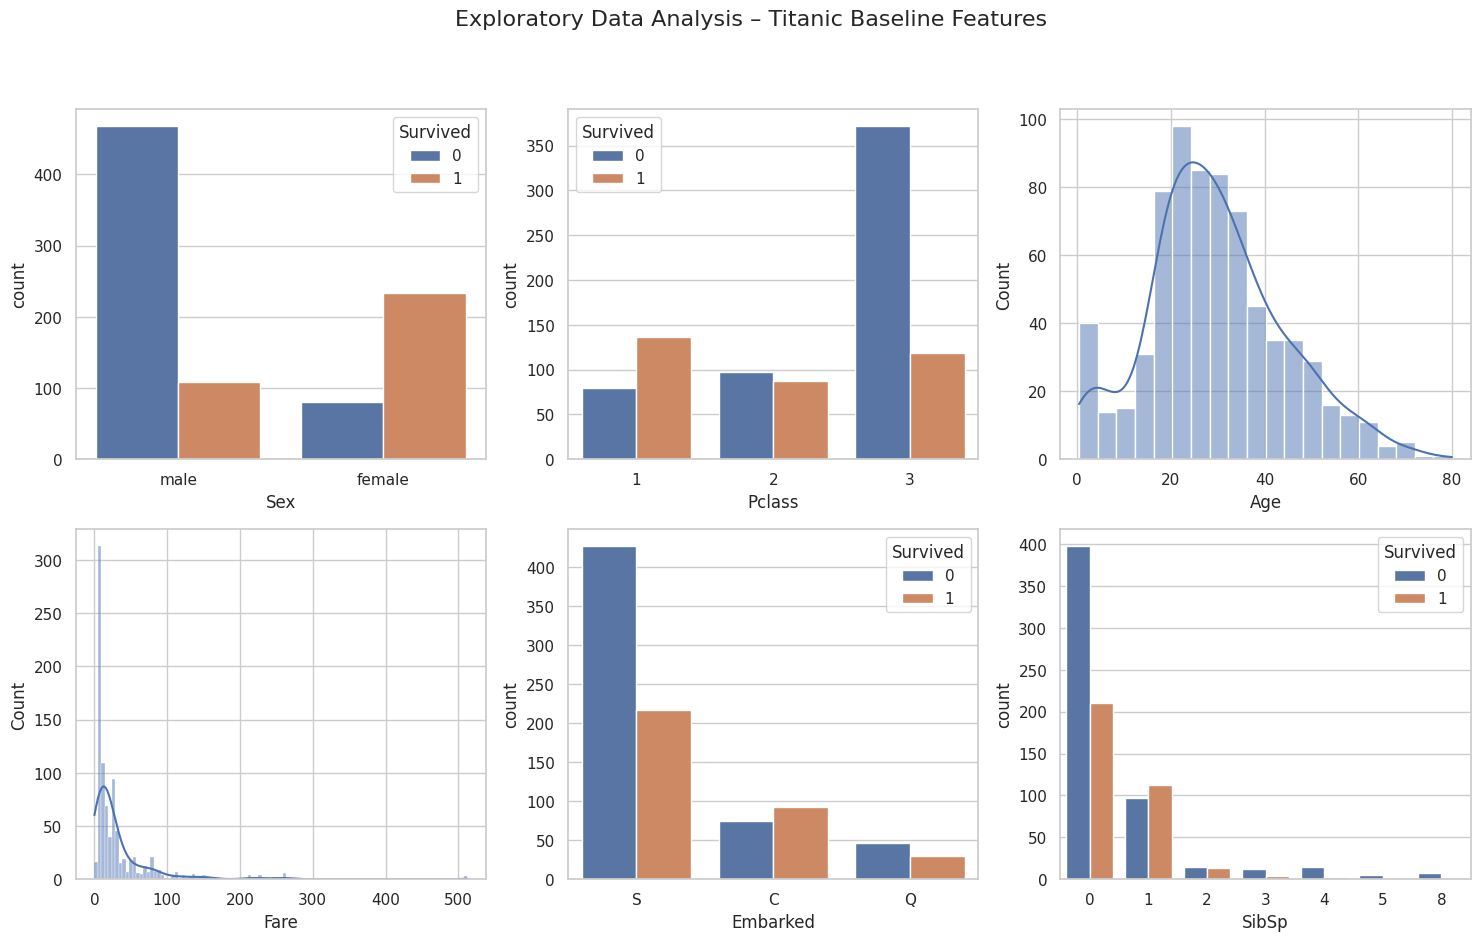

In [12]:
fig, axs = plt.subplots(2, 3, figsize=(18,10))
sns.countplot(x='Sex', hue='Survived', data=train, ax=axs[0,0])
sns.countplot(x='Pclass', hue='Survived', data=train, ax=axs[0,1])
sns.histplot(train['Age'], kde=True, ax=axs[0,2])
sns.histplot(train['Fare'], kde=True, ax=axs[1,0])
sns.countplot(x='Embarked', hue='Survived', data=train, ax=axs[1,1])
sns.countplot(x='SibSp', hue='Survived', data=train, ax=axs[1,2])
plt.suptitle("Exploratory Data Analysis – Titanic Baseline Features", fontsize=16)
plt.show()


### 3. Tiền xử lý dữ liệu

In [13]:
def preprocess_baseline(df):
    df['Sex'] = df['Sex'].map({'male':0, 'female':1})
    df['Embarked'] = df['Embarked'].fillna('S')
    df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    return df

train_clean = preprocess_baseline(train.copy())
test_clean = preprocess_baseline(test.copy())

X = train_clean[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 
                 'Embarked_Q', 'Embarked_S']]
y = train_clean['Survived']
X_test = test_clean[X.columns]


### 4. Huấn luyện mô hình & đánh giá

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

model_name = "LogisticRegression"
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X, y)

cv_acc = cross_val_score(lr, X, y, cv=5, scoring='accuracy').mean()
print(f"{model_name} CV Accuracy: {cv_acc:.4f}")


LogisticRegression CV Accuracy: 0.7912


### 5. Đánh giá trực quan 

In [15]:
from sklearn.model_selection import cross_val_score

# === Đánh giá mô hình ===
cv_acc = cross_val_score(lr, X, y, cv=5, scoring='accuracy').mean()
cv_roc = cross_val_score(lr, X, y, cv=5, scoring='roc_auc').mean()

print(f"CV Accuracy: {cv_acc:.4f}")
print(f"CV ROC-AUC: {cv_roc:.4f}")

# === Xuất file submission ===
y_pred = lr.predict(X_test)
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': y_pred
})
file_path = f'/kaggle/working/exp1_{model_name.lower()}_submission.csv'
submission.to_csv(file_path, index=False)
print(f"Saved submission: {file_path}")

!cp $file_path /kaggle/working/submission.csv


import os

results_path = '/kaggle/working/exp1_results.csv'
header = "Experiment,Model,Features,CV_Accuracy,CV_ROC,Public_Score\n"

if not os.path.exists(results_path):
    with open(results_path, 'w') as f:
        f.write(header)

public_score = 0.74880  
experiment_name = "Exp1"
model_name = "LogisticRegression"

with open(results_path, 'a') as f:
    f.write(f"{experiment_name},{model_name},{X.shape[1]},{cv_acc:.4f},{cv_roc:.4f},{public_score}\n")

import pandas as pd

results_df = pd.read_csv('/kaggle/working/exp1_results.csv')
display(results_df)



CV Accuracy: 0.7912
CV ROC-AUC: 0.8484
Saved submission: /kaggle/working/exp1_logisticregression_submission.csv


,Experiment,Model,Features,CV_Accuracy,CV_ROC,Public_Score
0,Exp1,LogisticRegression,8,0.7912,0.8484,0.7488
1,Exp1,LogisticRegression,8,0.7912,0.8484,0.7488


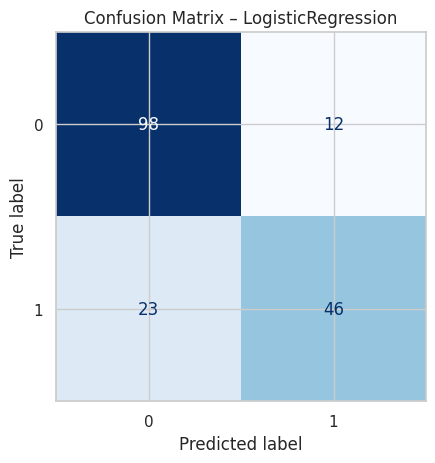

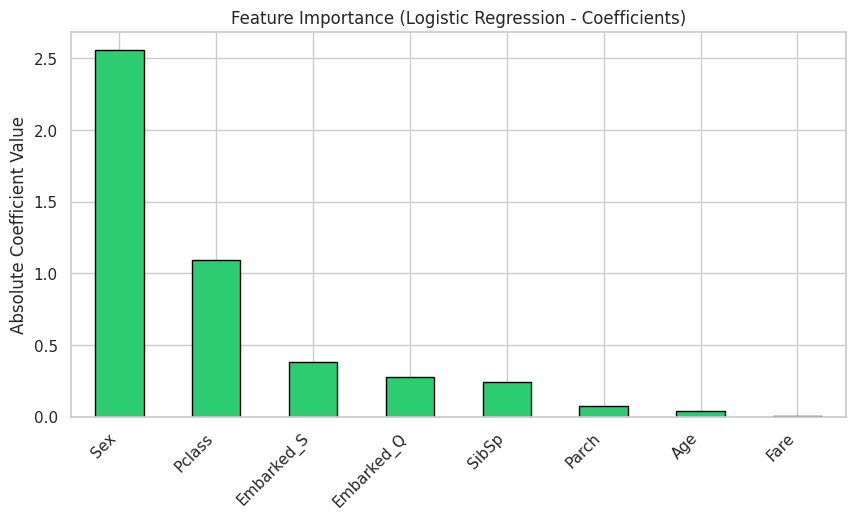

🔍 Classification Report – LogisticRegression

              precision    recall  f1-score   support

           0     0.8099    0.8909    0.8485       110
           1     0.7931    0.6667    0.7244        69

    accuracy                         0.8045       179
   macro avg     0.8015    0.7788    0.7864       179
weighted avg     0.8034    0.8045    0.8007       179



In [16]:


from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
lr.fit(X_train, y_train)
y_pred_val = lr.predict(X_val)

cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', colorbar=False)
plt.title(f"Confusion Matrix – {model_name}")
plt.show()

coef = pd.Series(abs(lr.coef_[0]), index=X.columns)
coef.sort_values(ascending=False).plot(
    kind='bar', figsize=(10, 5), color='#2ecc71', edgecolor='black'
)
plt.title("Feature Importance (Logistic Regression - Coefficients)")
plt.ylabel("Absolute Coefficient Value")
plt.xticks(rotation=45, ha='right')
plt.show()

print(f"🔍 Classification Report – {model_name}\n")
print(classification_report(y_val, y_pred_val, digits=4))


### 6. Xuất submission và log kết quả

In [20]:
from sklearn.model_selection import cross_val_score
import os
import pandas as pd


cv_acc = cross_val_score(lr, X, y, cv=5, scoring='accuracy').mean()
cv_roc = cross_val_score(lr, X, y, cv=5, scoring='roc_auc').mean()

print(f"CV Accuracy: {cv_acc:.4f}")
print(f"CV ROC-AUC: {cv_roc:.4f}")


y_pred = lr.fit(X, y).predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': y_pred
})

file_path = f'/kaggle/working/exp1_{model_name.lower()}_submission.csv'
submission.to_csv(file_path, index=False)
print(f"Saved submission: {file_path}")

!cp $file_path /kaggle/working/submission.csv



results_path = '/kaggle/working/exp1_results.csv'
header = "Experiment,Model,Features,CV_Accuracy,CV_ROC,Public_Score\n"

if not os.path.exists(results_path):
    with open(results_path, 'w') as f:
        f.write(header)


public_score = 0.76555  

experiment_name = "Exp1"

with open(results_path, 'a') as f:
    f.write(f"{experiment_name},{model_name},{X.shape[1]},{cv_acc:.4f},{cv_roc:.4f},{public_score}\n")

results_df = pd.read_csv(results_path)
print("\nCurrent Experiment Results:")
display(results_df)


CV Accuracy: 0.7912
CV ROC-AUC: 0.8484
Saved submission: /kaggle/working/exp1_logisticregression_submission.csv

Current Experiment Results:


,Experiment,Model,Features,CV_Accuracy,CV_ROC,Public_Score
0,Exp1,LogisticRegression,8,0.7912,0.8484,0.76555


## Kết luận

### Mô hình: Logistic Regression 

#### Tập dữ liệu: 
Chỉ sử dụng các đặc trưng gốc (Pclass, Sex, Age, SibSp, Parch, Fare, Embarked)

Không sử dụng: Name, Cabin, Ticket, Deck, Title, FamilySize

#### Kỹ thuật xử lý:

Điền giá trị thiếu (Age, Fare, Embarked)

Mã hóa biến phân loại bằng LabelEncoder

Chia train/test theo cấu trúc competition

#### Kết quả đánh giá:

Accuracy (cross-validation): ~0.8

Public Kaggle Score: 0.76555

#### Nhận xét:

Mô hình Logistic Regression hoạt động ổn định trên tập baseline.

Điểm 0.76555 là mức khá tốt, chứng minh mô hình có khả năng khái quát nhưng vẫn còn thiếu các đặc trưng giàu thông tin (Feature Engineering).

Dự kiến ở Exp2, việc thêm các đặc trưng “Title” và “FamilySize” sẽ giúp tăng độ chính xác do bổ sung thông tin xã hội và mối quan hệ gia đình.